In [1]:
import torch
from tqdm.auto import tqdm
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
from torch import nn

import matplotlib.pyplot as plt

In [2]:
## GETTING FASHION DATASET (FASHION MNIST)
#setup training data

train_data = datasets.FashionMNIST(
    root="data", #where to download data to
    train=True,  # do we want the training data set. False = test data
    download=True,
    transform=ToTensor(),# transform images into tensors
    target_transform=None #how do we want to transform the labels/targets
)

#setup testing data
test_data = datasets.FashionMNIST(
    root="data", #where to download data to
    train=False,  # do we want the training data set. False = test data
    download=True,
    transform=ToTensor(), # transform images into tensors
    target_transform=None #how do we want to transform the labels/targets
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 168kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.21MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.9MB/s]


In [3]:
len(train_data), len(test_data)

(60000, 10000)

In [4]:
# see the first training example
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [5]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

####Visualize our data

Image Shape: torch.Size([1, 28, 28])


Text(0.5, 1.0, '9')

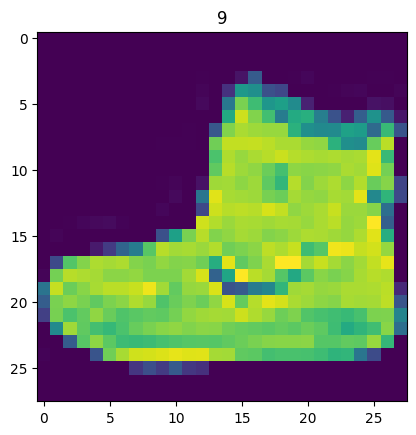

In [6]:
image, label = train_data[0]
print(f"Image Shape: {image.shape}")
plt.imshow(image.squeeze())
plt.title(label)

Text(0.5, 1.0, 'Ankle boot')

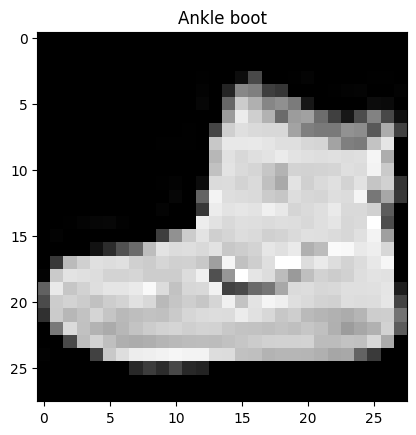

In [7]:
plt.imshow(image.permute(1, 2, 0), cmap='gray')
plt.title(class_names[label])

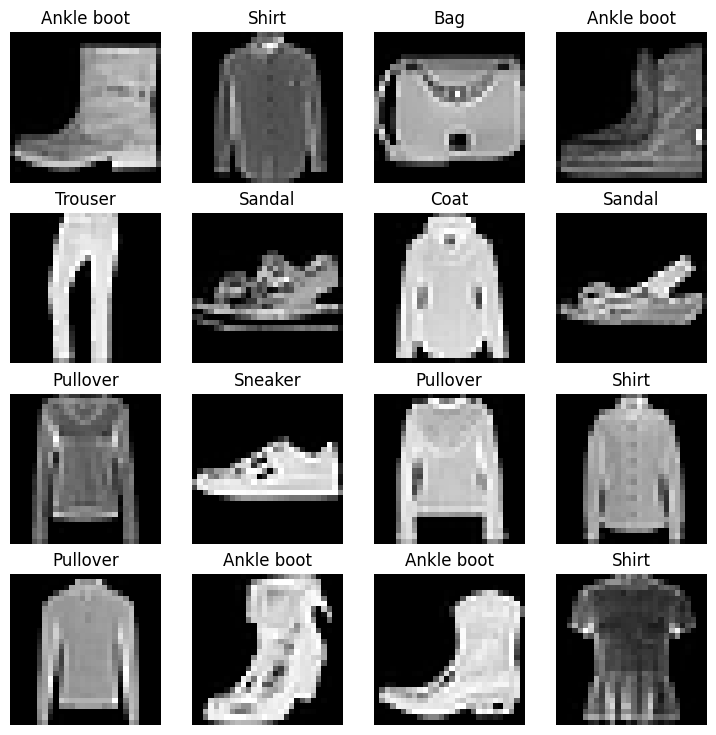

In [8]:
#plot more images
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
  random_idx = torch.randint(0 , len(train_data), size=[1]).item()
  img, label = train_data[random_idx]
  fig.add_subplot(rows, cols, i)
  plt.imshow(img.permute(1, 2, 0), cmap="gray")
  plt.title(class_names[label])
  plt.axis(False)

In [9]:
train_data, test_data

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

##### prepare data loader
Data Loader turns our dataset into pytorch iterable.

1. it is more computationally efficient. avoiding looking at all the images at the same time
2. it gives a neural network more chances to update its gradients

In [10]:
train_loader = DataLoader(dataset=train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(dataset=test_data, batch_size=32, shuffle=False)
train_loader, test_loader

(<torch.utils.data.dataloader.DataLoader at 0x78e54071ce30>,
 <torch.utils.data.dataloader.DataLoader at 0x78e540793d70>)

In [11]:
#Check what we created
print(f"Length of train_loader: {len(train_loader)} batches of 32")
print(f"Length of test_loader: {len(test_loader)} batches of 32")

Length of train_loader: 1875 batches of 32
Length of test_loader: 313 batches of 32


In [12]:
train_features_batch, train_labels_batch = next(iter(train_loader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

img shape: torch.Size([1, 28, 28])
tensor(0.3765)


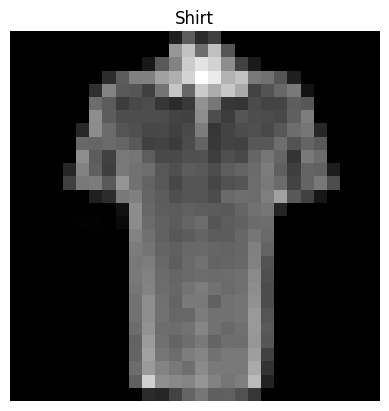

In [13]:
#show a sample from a batch
torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img,label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap='gray')
plt.title(class_names[label])
plt.axis(False)
print(f"img shape: {img.shape}")
print(img[0][13][13])

In [14]:
## Building a baseline model (simple model that we will be improving)

#Creating a Flatting model. https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.flatten.Flatten.html

flatten_model = nn.Flatten()
#get a simple sample
x = train_features_batch[0]
x.shape

torch.Size([1, 28, 28])

In [15]:
#It transform the matrix of [1,28,28] into a single matrix of [1,784] (transform all dimensions into a single single dimension)
output = flatten_model(x)
output.shape

torch.Size([1, 784])

In [16]:
class FashionModelV0(nn.Module):
  def __init__(self,
               input_shape,
               hidden_units,
               output_shape):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=output_shape)
    )

  def forward(self, x):
    return self.layer_stack(x)

In [17]:
torch.manual_seed(42)
model_0 = FashionModelV0(input_shape=784, #obtuve esto del flatten. dado que es la primera operacion que se realiza antes de pasar a las capas ocultas
                        hidden_units=10,
                        output_shape=len(class_names))
model_0

FashionModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [18]:
softmax = nn.Softmax(dim=1)
logits = model_0(x)
class_name = softmax(logits).argmax(dim=1)


In [54]:
def imgshow(x, class_idx):
  plt.imshow(x.squeeze(), cmap='gray')
  plt.axis(False)
  plt.title(class_names[class_idx])

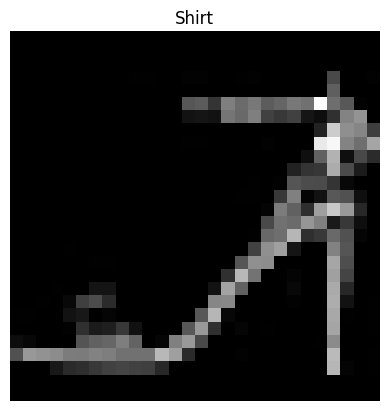

In [20]:
imgshow(x, class_name) #incorrect prediction

#### Create a loss function and optimizer

Loss function - CrosEntropyLoss
Optimizer - ADAM
Evaluation Metric - Accuracy


In [21]:
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct / len(y_pred)) * 100
  return acc

In [22]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params= model_0.parameters(),
                             lr=0.1)

In [23]:
torch.manual_seed(42)
EPOCHS = 3
for epoch in tqdm(range(EPOCHS)):
  print(f"Epoch: [{epoch}/{EPOCHS}]")
  train_loss = 0
  for batch, (X, y) in enumerate(train_loader):
    model_0.train()
    y_pred = model_0(X)
    loss = loss_fn(y_pred, y)
    train_loss += loss # accumulate the error across every batch
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if batch % 400 == 0:
      print(f"Looked at {batch * len(X)}/{len(train_loader.dataset)} samples")
  train_loss /= len(train_loader) #devide total train loss by length of train dataloader
  print(f"Train Loss: {train_loss:.5f}")

  test_loss, test_acc = 0, 0
  with torch.inference_mode():
    model_0.eval()
    for X_test, y_test in test_loader:
      test_pred = model_0(X_test)
      #calculate loss cumulatively
      test_loss += loss_fn(test_pred, y_test)
      #calculate accuracy
      test_acc += accuracy_fn(y_true=y_test, y_pred=test_pred.argmax(dim=1))
    #calculate average test loss per epoch
    test_loss /= len(test_loader)
    #calculate average accuracy per epoch
    test_acc /= len(test_loader)
  print(f"\nTrain Loss: {train_loss:4f} | Test Loss: {test_loss:4f} | Test Accuraccy: {test_acc:4f}")


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: [0/3]
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train Loss: 2.91054

Train Loss: 2.910535 | Test Loss: 2.292654 | Test Accuraccy: 74.690495
Epoch: [1/3]
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train Loss: 3.43212

Train Loss: 3.432117 | Test Loss: 2.650365 | Test Accuraccy: 78.484425
Epoch: [2/3]
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train Loss: 3.41116

Train Loss: 3.411161 | Test Loss: 4.234633 | Test Accuraccy: 71.066294


#### Make predictions and get model 0 results

In [24]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn):
  loss, acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X, y in tqdm(data_loader):
      #Maker predictions
      y_pred = model(X)
      #Accumulate the loss and acc values per batch
      loss+= loss_fn(y_pred, y)
      acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))
    loss /= len(data_loader)
    acc /= len(data_loader)
  return { "model_name": model.__class__.__name__, "model_loss": loss.item(), "model_acc": acc }



model_0_results = eval_model(model=model_0,
                             data_loader=test_loader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn)

model_0_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionModelV0',
 'model_loss': 4.234633445739746,
 'model_acc': 71.06629392971246}

In [25]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

### Model 1. Non Linearity with cuda

In [26]:
class FashionModelV1(nn.Module):
  def __init__(self,
               input_shape,
               hidden_units_1,
               hidden_units_2,
               output_shape):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units_1),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units_1, out_features=hidden_units_2),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units_2, out_features=output_shape))

  def forward(self, x):
    return self.layer_stack(x)

In [27]:
torch.manual_seed(42)
model_1 = FashionModelV1(input_shape=28 * 28,
                        hidden_units_1=128,
                         hidden_units_2=64,
                        output_shape=len(class_names)).to(device)
model_1

FashionModelV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [28]:
loss_fn_1 = nn.CrossEntropyLoss()
optimizer_1 = torch.optim.Adam(params=model_1.parameters(),lr=0.001)

In [45]:
def train_model(target_model: torch.nn.Module,
                loader_train: torch.utils.data.DataLoader,
                loss_function: torch.nn.Module,
                optimizer_function: torch.optim.Optimizer,
                accuracy_function,
                epochs,
                device):

  torch.manual_seed(42)
  for epoch in tqdm(range(epochs)):
    train_loss = 0
    for batch, (X, y) in enumerate(loader_train):
      target_model.train()
      y_pred = target_model(X.to(device))
      loss = loss_function(y_pred, y.to(device))
      train_loss += loss
      optimizer_function.zero_grad()
      loss.backward()
      optimizer_function.step()
    train_loss /= len(loader_train)
    print(f"Epoch: [{epoch}/{epochs}] | Train Loss: {train_loss:.5f}")

def test_model(target_model: torch.nn.Module,
               loader_test: torch.utils.data.DataLoader,
               loss_function: torch.nn.Module,
               accuracy_function,
               device):
  test_loss, test_acc = 0, 0
  with torch.inference_mode():
    target_model.eval()
    for X_test, y_test in loader_test:
      test_pred = target_model(X_test.to(device))
      test_loss += loss_function(test_pred, y_test.to(device))
      test_acc += accuracy_function(y_true=y_test.to(device), y_pred=test_pred.argmax(dim=1))
    test_loss /= len(loader_test)
    test_acc /= len(loader_test)
  print(f"\nTrain Loss: {train_loss:4f} | Test Loss: {test_loss:4f} | Test Accuraccy: {test_acc:4f}")

In [30]:
train_model(target_model= model_1,
            loader_train= train_loader,
            loss_function= loss_fn_1,
            optimizer_function= optimizer_1,
            accuracy_function= accuracy_fn,
            epochs= 20,
            device=device)

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: [0/20] | Train Loss: 0.51522
Epoch: [1/20] | Train Loss: 0.37149
Epoch: [2/20] | Train Loss: 0.33526
Epoch: [3/20] | Train Loss: 0.31279
Epoch: [4/20] | Train Loss: 0.29400
Epoch: [5/20] | Train Loss: 0.28020
Epoch: [6/20] | Train Loss: 0.26815
Epoch: [7/20] | Train Loss: 0.25452
Epoch: [8/20] | Train Loss: 0.24695
Epoch: [9/20] | Train Loss: 0.23656
Epoch: [10/20] | Train Loss: 0.22843
Epoch: [11/20] | Train Loss: 0.22059
Epoch: [12/20] | Train Loss: 0.21572
Epoch: [13/20] | Train Loss: 0.20666
Epoch: [14/20] | Train Loss: 0.20047
Epoch: [15/20] | Train Loss: 0.19429
Epoch: [16/20] | Train Loss: 0.18928
Epoch: [17/20] | Train Loss: 0.18482
Epoch: [18/20] | Train Loss: 0.18015
Epoch: [19/20] | Train Loss: 0.17599


In [31]:
test_model(target_model= model_1,
            loader_test= test_loader,
            loss_function= loss_fn_1,
            accuracy_function= accuracy_fn,
            device= device)


Train Loss: 3.411161 | Test Loss: 0.355114 | Test Accuraccy: 89.646565


In [32]:
### Get model_1 results
def eval_model_with_device(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device):
  loss, acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X, y in tqdm(data_loader):
      #Maker predictions
      X, y = X.to(device), y.to(device)
      y_pred = model(X)
      #Accumulate the loss and acc values per batch
      loss+= loss_fn(y_pred, y)
      acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))
    loss /= len(data_loader)
    acc /= len(data_loader)
  return { "model_name": model.__class__.__name__, "model_loss": loss.item(), "model_acc": acc }


model_1_results = eval_model_with_device(model=model_1,
                             data_loader=test_loader,
                             loss_fn=loss_fn_1,
                             accuracy_fn=accuracy_fn,
                             device=device)

model_1_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionModelV1',
 'model_loss': 0.35511407256126404,
 'model_acc': 89.64656549520767}

In [33]:
model_0_results

{'model_name': 'FashionModelV0',
 'model_loss': 4.234633445739746,
 'model_acc': 71.06629392971246}

### Create first convulutional NN

In [57]:
#Copy TinyVGG architecture from https://poloclub.github.io/cnn-explainer/
class FashionModelV2(nn.Module):
  def __init__(self,
               input_shape,
               hidden_units,
               output_shape):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)) #reduce 28x28 to 14x14
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)) # reduce 14x14 to 7x7
    self.classifier = nn.Sequential(
      nn.Flatten(),
      nn.Linear(in_features=hidden_units*7*7, out_features=output_shape))

  def forward(self,x):
    x = self.conv_block_1(x)
    x = self.conv_block_2(x)
    x = self.classifier(x)
    return x


In [58]:
torch.manual_seed(42)
model_2 = FashionModelV2(input_shape=1,
                         hidden_units=10,
                         output_shape=len(class_names)).to(device)
model_2

FashionModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [43]:
logits = model_2(x.unsqueeze(dim=0).to(device))
logits

tensor([[ 0.0272, -0.0568,  0.0470, -0.0237, -0.0181,  0.0137, -0.0053, -0.0106,
          0.0235,  0.0163]], device='cuda:0', grad_fn=<AddmmBackward0>)

#### Train Tiny VGG model (model v2)



In [59]:
loss_fn_2 = nn.CrossEntropyLoss()
optimizer_2 = torch.optim.Adam(params=model_2.parameters(),lr=0.001)
train_model(target_model=model_2,
            loader_train=train_loader,
            loss_function=loss_fn_2,
            optimizer_function= optimizer_2,
            accuracy_function=accuracy_fn,
            epochs=200,
            device=device)

test_model(target_model=model_2,
            loader_test=test_loader,
            loss_function=loss_fn_2,
            accuracy_function=accuracy_fn,
            device=device)


  0%|          | 0/200 [00:00<?, ?it/s]

Epoch: [0/200] | Train Loss: 0.53750
Epoch: [1/200] | Train Loss: 0.35868
Epoch: [2/200] | Train Loss: 0.32510
Epoch: [3/200] | Train Loss: 0.30219
Epoch: [4/200] | Train Loss: 0.28321
Epoch: [5/200] | Train Loss: 0.27063
Epoch: [6/200] | Train Loss: 0.26068
Epoch: [7/200] | Train Loss: 0.25081
Epoch: [8/200] | Train Loss: 0.24437
Epoch: [9/200] | Train Loss: 0.23683
Epoch: [10/200] | Train Loss: 0.23024
Epoch: [11/200] | Train Loss: 0.22559
Epoch: [12/200] | Train Loss: 0.22234
Epoch: [13/200] | Train Loss: 0.21510
Epoch: [14/200] | Train Loss: 0.21331
Epoch: [15/200] | Train Loss: 0.20839
Epoch: [16/200] | Train Loss: 0.20506
Epoch: [17/200] | Train Loss: 0.20341
Epoch: [18/200] | Train Loss: 0.19995
Epoch: [19/200] | Train Loss: 0.19812
Epoch: [20/200] | Train Loss: 0.19463
Epoch: [21/200] | Train Loss: 0.19320
Epoch: [22/200] | Train Loss: 0.18994
Epoch: [23/200] | Train Loss: 0.18819
Epoch: [24/200] | Train Loss: 0.18771
Epoch: [25/200] | Train Loss: 0.18520
Epoch: [26/200] | Trai

In [70]:
pred_logits = model_2(x.unsqueeze(dim=0).to(device))
pred_prob = torch.softmax(pred_logits.squeeze(), dim=0).cpu()
pred_idx = pred_prob.argmax(dim=0)
pred_class_name = class_names[pred_idx]
pred_class_name

'Sandal'

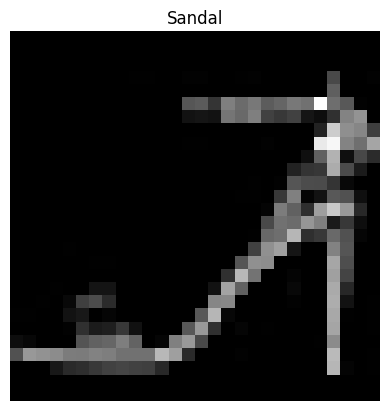

In [61]:
imgshow(x, pred_idx)

#### Evaluate predictions

In [62]:
def make_predictions(model: torch.nn.Module,
                     data: list,
                     device: torch.device = device):
  pred_probs = []
  model.eval()
  with torch.inference_mode():
    for sample in data:
      #Prepare sample
      sample = torch.unsqueeze(sample, dim=0).to(device)
      #Make prediction
      pred_logit = model(sample)
      pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)
      pred_probs.append(pred_prob.cpu())
  return torch.stack(pred_probs)

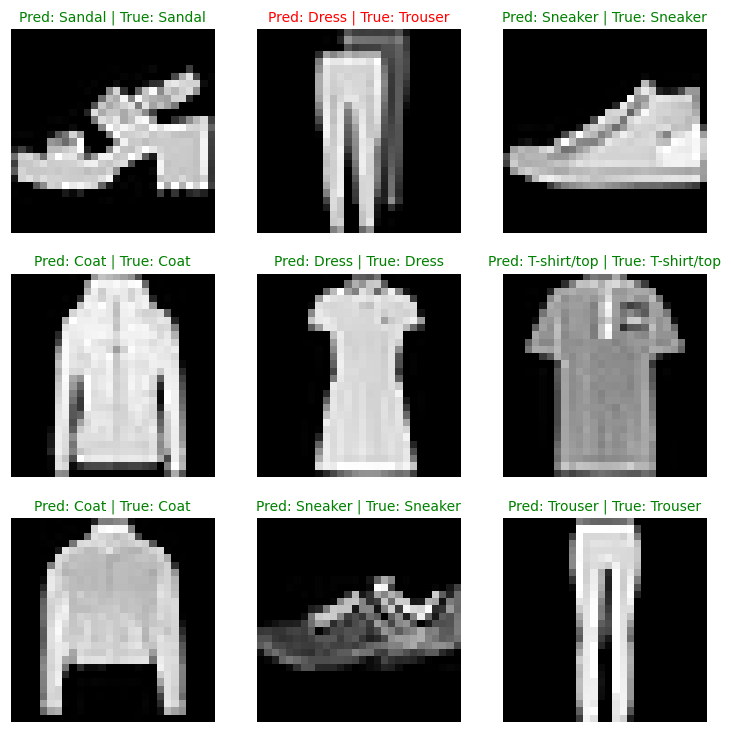

In [63]:
import random
test_samples = []
test_labels = []

for sample, label in random.sample(list(test_data), k=9):
  test_samples.append(sample)
  test_labels.append(label)

# 9 prediction probabilities
pred_probs = make_predictions(model=model_2, data=test_samples)
#convert prediction probs into pred labels
pred_labels = pred_probs.argmax(dim=1)


plt.figure(figsize=(9,9))
plt.axis(False)
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
  #create subplot
  plt.subplot(nrows, ncols, i+1)
  #plot the target image
  plt.imshow(sample.squeeze(), cmap='gray')
  plt.axis(False)
  #find the prediction
  pred_label = class_names[pred_labels[i]]
  true_label = class_names[test_labels[i]]
  #create a title for the plot
  title_text = f"Pred: {pred_label} | True: {true_label}"
  if pred_label == true_label:
    plt.title(title_text, fontsize=10, color='green')
  else:
    plt.title(title_text, fontsize=10, color='red')






### Save the Model

In [72]:
from pathlib import Path

MODEL_PART = Path("models")
MODEL_PART.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "fashion_model_tiny_vgg_v2.pth"
MODEL_SAVE_PATH = MODEL_PART / MODEL_NAME

## save the model
torch.save(obj=model_2.state_dict(), f=MODEL_SAVE_PATH)